# Network Analysis -- Assignment 01
## A Network of Thrones: Characterising the Game of Thrones Character Network

**Course:** Network Analysis 2025/26  
**Submission Date:** Via Moodle, 27/03/2025
**Group size:** 3 students  
**Group:** \
Member 1: Beatriz Marques -- 20231605 \
Member 2: Maria Inês Santos -- 20231630 \
Member 3: Luís Rafael da Costa Soeiro -- 20211536 \
Member 4: Rodrigo --

**Submission instructions** 
Rename this file to include your group identifier before submitting. The file name should follow the format Assignment01_GroupX.ipynb, where X is replaced by your group letter or number (for example, Assignment01_GroupA.ipynb).
Inside the notebook, fill in the cell below with the names and student numbers of all three group members before beginning the assignment. Submissions missing this information will not be graded.

### Overview

In this assignment you will analyse a real-world network derived from George R.R. Martin's *A Song of Ice and Fire*, the book series on which Game of Thrones is based. Two characters are linked if their names appear within 15 words of each other in the text of Book 1. The weight of each edge reflects how frequently this co-occurrence takes place.

Your task is to characterise this network using the metrics and methods covered in lectures and labs, and to draw meaningful conclusions about the social structure of the story from the results.

**Dataset:** Network of Thrones (Beveridge and Shan, 2016)  
**Source:** https://raw.githubusercontent.com/mathbeveridge/asoiaf/master/data/asoiaf-book1-edges.csv

---

### Grading criteria

| Points | Description |
|--------|-------------|
| 0      | Not delivered |
| 10     | Delivered but incomplete |
| 15     | Complete but not all expected outputs achieved |
| 20     | Complete and all expected outputs achieved |

---

## Part 0 -- Setup

Run the cell below before starting.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go


%matplotlib inline
print(f"NetworkX version: {nx.__version__}")
print("Ready.")

NetworkX version: 3.6.1
Ready.


---

## Part 1 -- Load and Build the Network

### 1.1 -- Load the dataset

Load the edge list from the URL above into a Pandas DataFrame and display the first few rows.

In [2]:
df = pd.read_csv('book_edges.csv')
df.head(10)

,Source,Target,Type,weight,book
0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1
1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1
2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1
3,Aegon-I-Targaryen,Eddard-Stark,Undirected,4,1
4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Undirected,4,1
5,Aemon-Targaryen-(Maester-Aemon),Bowen-Marsh,Undirected,4,1
6,Aemon-Targaryen-(Maester-Aemon),Chett,Undirected,9,1
7,Aemon-Targaryen-(Maester-Aemon),Clydas,Undirected,5,1
8,Aemon-Targaryen-(Maester-Aemon),Jeor-Mormont,Undirected,13,1
9,Aemon-Targaryen-(Maester-Aemon),Jon-Snow,Undirected,34,1


### 1.2 -- Build the graph

Construct a NetworkX graph from the DataFrame. Ensure that the edge weight attribute is included.

Hint: use `nx.from_pandas_edgelist()` and inspect the column names in your DataFrame beforehand.

In [3]:
print(list(df.columns))

G = nx.from_pandas_edgelist(
    df,
    source="Source",
    target="Target",
    edge_attr="weight",   
    create_using=nx.Graph() # undirected
    )

['Source', 'Target', 'Type', 'weight', 'book']


### 1.3 -- Basic properties

Report the following:
- Number of nodes (N)
- Number of edges (L)
- Whether the graph is directed or undirected
- Whether the graph is weighted

In [4]:
# Number of nodes (N)
N = G.number_of_nodes()

# Number of edges (L)
L = G.number_of_edges()

# Directed or undirected
is_directed = G.is_directed()

# Weighted
is_weighted = nx.is_weighted(G)

print("Number of nodes (N):", N)
print("Number of edges (L):", L)
print("Directed:", is_directed)
print("Weighted:", is_weighted)

Number of nodes (N): 187
Number of edges (L): 684
Directed: False
Weighted: True


### 1.4 -- Visualise the network

Produce a plot of the network. Use node size or colour to encode a meaningful property such as degree. The network is large, so full readability of labels is not expected.

In [5]:
# Compute layout
pos = nx.spring_layout(G, k=0.3, iterations=20, seed=42) # k changes distance between nodes

# Node degree
degrees = dict(G.degree())

# Normalize sizes for better visualization
node_sizes = [5 + degrees[node]*2 for node in G.nodes()] # if we want to see degree diferenciation using node size
node_colors = [degrees[node] for node in G.nodes()] # if we want to see degree diferenciation using color scale

# Create edge traces
edge_x = []
edge_y = []

for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=0.5),
    hoverinfo='none',
    mode='lines'
)

# Create node traces
node_x = []
node_y = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        size=18, # use node_sizes here
        color=node_colors,
        colorscale='Inferno',
        showscale=True,
        colorbar=dict(title='Degree'),
        line_width=0.5
    )
)

# hover text + figure
node_text = [f"{node}<br>Degree: {degrees[node]}" for node in G.nodes()]
node_trace.text = node_text
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                title=dict(
                    text="Game of Thrones character network graph",
                    x=0.5,       
                    xanchor='center',
                    yanchor='top',
                    font=dict(
                        family="Tahoma",
                        size=24,
                        color="black"
                    )),
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                width=1400,
                height=800,
                xaxis=dict(showgrid=False, zeroline=False, visible=False),
                yaxis=dict(showgrid=False, zeroline=False, visible=False)
                ))

fig.show()

---

## Part 2 -- Degree Distribution

### 2.1 -- Compute degree

Compute the degree of every node. Report the 10 highest-degree characters.

In [6]:
# degree sorted
top_10 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]

# 10 highest degrees
print("Top 10 highest-degree characters:")
top_10_df = pd.DataFrame(top_10, columns=["Character", "Degree"])
top_10_df

Top 10 highest-degree characters:


,Character,Degree
0,Eddard-Stark,66
1,Robert-Baratheon,50
2,Tyrion-Lannister,46
3,Catelyn-Stark,43
4,Jon-Snow,37
5,Robb-Stark,35
6,Sansa-Stark,35
7,Bran-Stark,32
8,Cersei-Lannister,30
9,Joffrey-Baratheon,30


### 2.2 -- Plot the degree distribution

Plot the degree distribution. Include clearly labelled axes and a title. Consider whether a log-log representation reveals additional structure.

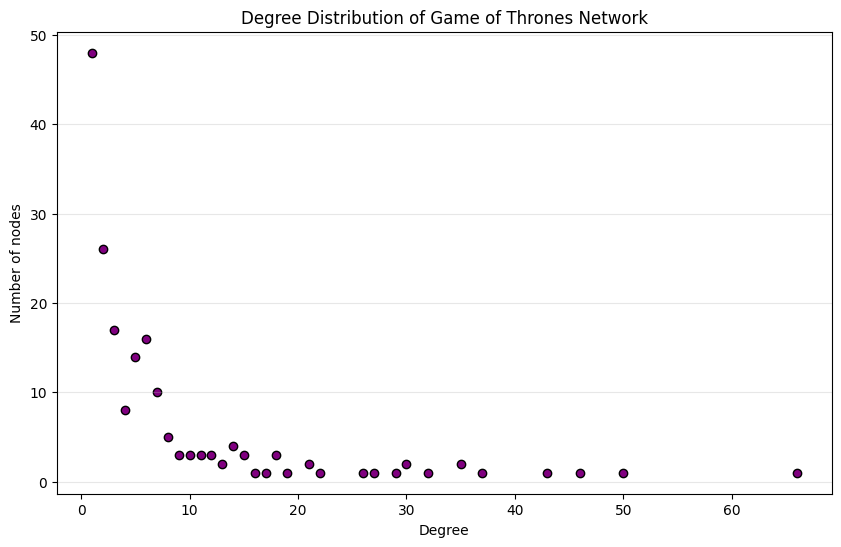

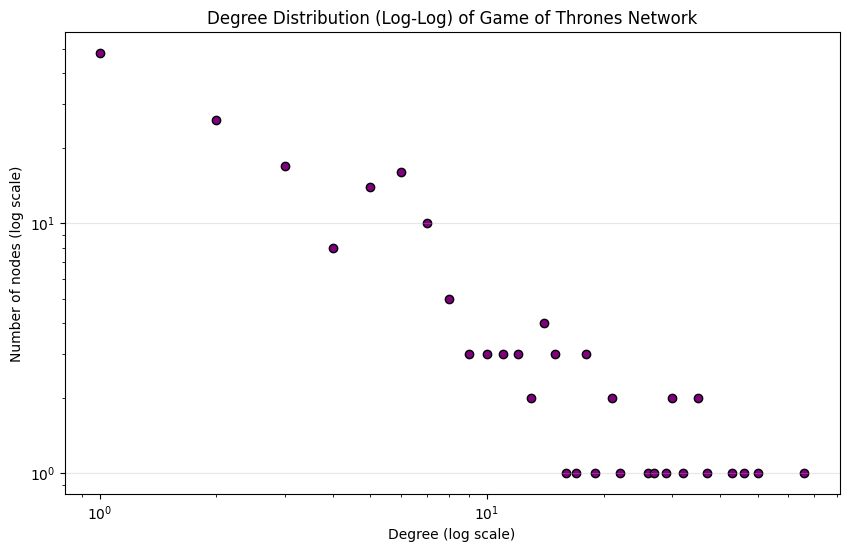

In [8]:
# degree frequency
degrees = [d for n, d in G.degree()]
degree_counts = {}
for d in degrees:
    degree_counts[d] = degree_counts.get(d, 0) + 1

# Sort degrees for plotting
deg, cnt = zip(*sorted(degree_counts.items()))

# --- Linear scale plot ---
plt.figure(figsize=(10, 6))
plt.scatter(deg, cnt, color='purple', edgecolor='black')
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Degree Distribution of Game of Thrones Network")
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- Log-log scale plot ---
plt.figure(figsize=(10, 6))
plt.scatter(deg, cnt, color='purple', edgecolors='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Degree (log scale)")
plt.ylabel("Number of nodes (log scale)")
plt.title("Degree Distribution (Log-Log) of Game of Thrones Network")
plt.grid(axis='y', alpha=0.3)
plt.show()

### 2.3 -- Discussion

1. What is the average degree of the network?
2. What is the shape of the degree distribution and what does it indicate about the network?
3. Do the highest-degree characters reflect their narrative importance in Book 1?

*Your answer here*

1. 
2. 
3. 

---

## Part 3 -- Clustering

### 3.1 -- Average clustering coefficient

Compute and report:

- The average clustering coefficient

In [ ]:
# Your code here


### 3.2 -- Local clustering

Compute the local clustering coefficient for each node. Report the 10 characters with the highest values.

In [ ]:
# Your code here


### 3.3 -- Discussion

1. How would you interpret the clustering coefficient values obtained? What do they suggest about the social structure in Book 1?
2. Do the characters with the highest local clustering tend to belong to the same group or faction? What might explain this?

*Your answer here*

1. 
2. 

---

## Part 4 -- Paths and Connectivity

### 4.1 -- Average path length and diameter

Compute the average shortest path length and the diameter of the network.

In [ ]:
# Your code here


### 4.2 -- Assortativity Mixing
Compute assortativity (r) and print r for the network.

In [ ]:
# Your code here


### 4.4 -- Discussion

1. Is the average path length short relative to the number of nodes? What does this imply about the network?
2. What does the assortativity r value tells us?

*Your answer here*

1. 
2. 

---

## Part 5 -- Weighted Analysis

### 5.1 -- Node strength

Compute the strength of each node, defined as the sum of its edge weights. Report the 10 characters with the highest strength.

In [ ]:
# Your code here


### 5.2 -- Degree versus strength

Construct a DataFrame containing the degree and strength of each character. Sort by strength and display the top 15 entries.

In [ ]:
# Your code here


### 5.3 -- Strongest edges

Report the 10 pairs of characters with the highest edge weight.

In [ ]:
# Your code here


### 5.4 -- Discussion

1. Do the degree and strength rankings agree? Where they diverge, what does this reveal about a character's interaction patterns?
2. Do the strongest character pairs correspond to meaningful relationships in Book 1?

*Your answer here*

1. 
2. 

---

## Part 6 -- Gephi Visualisation: Bridges versus Embedded Characters

### Context

The metrics computed in the previous parts give us a numerical picture of the network, but a well-designed visualisation can communicate structure at a glance. In this part you will use Gephi to produce a visual representation of the full character network that makes the most important characters and relationships immediately legible.

### 6.1 -- Prepare node attributes

Compute the strength of each node (sum of edge weights) for all nodes in the giant component. Store the results in a DataFrame and display it. You will use this to drive node sizing in Gephi.

In [ ]:
# Your code here


### 6.2 -- Export the graph for Gephi

Attach node strength as a node attribute and export the giant component to a GEXF file using nx.write_gexf().

In [ ]:
# Your code here


### 6.3 -- Gephi instructions

Open the exported GEXF file in Gephi and apply the following settings.

**Layout:** Run ForceAtlas 2 until the graph stabilises. This places highly connected nodes near the centre and peripheral characters at the edges. [You can also use other layouts]

**Node size:** Map to node strength using the Appearance panel under Nodes, Size, Ranking. Set a minimum size of 5 and a maximum of 40. Larger nodes represent characters with the most cumulative interaction across the book.

**Node colour:** Apply a single neutral colour to all nodes (for example, a warm grey). The focus of this visualisation is on the edges, so node colour should not compete for attention.

**Edge thickness:** Map to edge weight using the Appearance panel under Edges, Size, Ranking. This makes the strongest character relationships visually dominant.

**Labels:** Display names only for the top 10 nodes by strength. Disable labels for all other nodes to keep the visualisation readable.

Once satisfied with the layout, export the image as a PNG file from File, Export, SVG/PDF/PNG.

In [ ]:
from IPython.display import Image
Image('got_book1_gephi.png')

### 6.5 -- Discussion

Interpret your visualisation. Address the following:

1. Which characters appear as the largest nodes? Does their size reflect their importance in the story?
2. Which edges appear thickest? Do the strongest character pairs correspond to meaningful relationships in Book 1?
3. Does the overall layout reveal any structure -- for example, clusters of characters who are densely connected to each other but loosely connected to the rest of the network?

*Your answer here*

1. 
2. 
3. 

---

## Part 7 -- Synthesis

Drawing on all parts of this assignment, answer the following questions. Aim for two to four sentences per question.

**7.1** -- Who is the most central character in Book 1? Support your answer with at least two distinct metrics.

*Your answer here*

**7.2** -- Does the network exhibit evidence of community structure? What metrics or observations support your conclusion?

*Your answer here*

**7.3** -- Based on the full set of metrics computed, would you characterise this as a random or a structured network? Justify your answer.

*Your answer here*

**7.4** -- What is the most notable finding from your analysis, and what would you investigate further given additional time?

*Your answer here*

---

*End of Assignment 01. Submit this notebook and your Gephi image via Moodle.*